In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from pathlib import Path

import torch
_ = torch.manual_seed(3247)

# Set up CUDA if 
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

False


In [24]:
DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../results/advanced")

PARAM_NAMES = ["beta", "gamma", "rho"]

PARAM_LABELS = {
    "beta": r"$\beta$",
    "gamma": r"$\gamma$",
    "rho": r"$\rho$"
}

EPS = [0.1, 0.01, 0.001]

SUMMARY_NAMES = [
    "mean:auc_infected_fraction",
    "sd:auc_infected_fraction",
    "mean:peak_infected_fraction",
    "sd:peak_infected_fraction",
    "mean:time_to_peak_infected_fraction",
    "sd:time_to_peak_infected_fraction",
    "mean:initial_growth_ratio",
    "sd:initial_growth_ratio",
    "mean:peak_rewire_count",
    "sd:peak_rewire_count",
    "mean:time_to_peak_rewire_count",
    "sd:time_to_peak_rewire_count",
    "mean:total_rewire_count",
    "sd:total_rewire_count",
    "mean:mean_degree",
    "sd:mean_degree",
    "mean:sd_degree",
    "sd:sd_degree",
    "mean:rewire_to_infection_ratio",
    "sd:rewire_to_infection_ratio",
    "mean:lag_peak",
    "sd:lag_peak"
]

print(len(SUMMARY_NAMES))

22


In [3]:
reference_table = pd.read_csv(DATA_DIR / "sim/reference_table.csv")
obs_data_sim = pd.read_csv(DATA_DIR / "sim/test_set.csv")
obs_data_raw = pd.read_csv(DATA_DIR / "raw/observed_stats_raw.csv")

full_stats = reference_table[SUMMARY_NAMES].values
full_params = reference_table[PARAM_NAMES].values

obs_data = {
    0.1: obs_data_sim[:100],
    0.01: obs_data_sim[100:200],
    0.001: obs_data_sim[200:300]
}

In [4]:
N_TRAIN = 10_000
train_data = reference_table.sample(n=N_TRAIN, random_state=3247)
train_params = train_data[PARAM_NAMES].values
train_stats = train_data[SUMMARY_NAMES].values

obs_stats = obs_data_raw[SUMMARY_NAMES].values

theta = torch.as_tensor(train_params, dtype=torch.float32)
x =     torch.as_tensor(train_stats, dtype=torch.float32)
x_obs = torch.as_tensor(obs_stats, dtype=torch.float32)

print(theta.shape)
print(x.shape)
print(x_obs.shape)

torch.Size([10000, 3])
torch.Size([10000, 22])
torch.Size([1, 22])


In [5]:
from sbi.inference import NPE
from sbi.utils import BoxUniform

lower_bound = torch.as_tensor([0.05, 0.02, 0.0])
upper_bound = torch.as_tensor([0.50, 0.20, 0.8])

theta = torch.tensor(theta, dtype=torch.float32).to(device)
x     = torch.tensor(x,     dtype=torch.float32).to(device)

prior = BoxUniform(low=lower_bound.to(device), high=upper_bound.to(device))

inference = NPE(
    prior=prior,
    density_estimator="maf",
    device=device,
)

posterior_net = inference.append_simulations(theta, x).train()

c:\Users\ningc\Documents\university\bachelor-4\semester-2\simulation\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ningc\AppData\Local\Temp\ipykernel_29404\1121211686.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32).to(device)
C:\Users\ningc\AppData\Local\Temp\ipykernel_29404\1121211686.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x     = torch.tensor(x,     dtype=torch.float32).to(device)
c:\Users\ningc\Documents\university\bachelor

 Neural network successfully converged after 211 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\ningc\Documents\university\bachelor-4\semester-2\simulation\project\analysis\sbi-logs\NPE_C\2026-04-19T16_08_11.547177' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


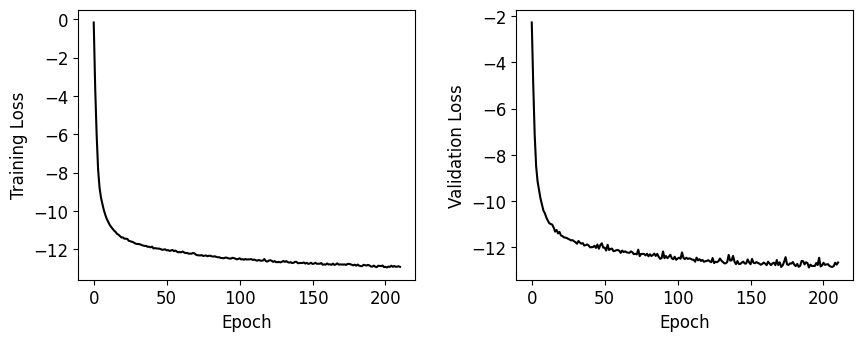

In [7]:
from sbi.analysis import plot_summary

fig, ax = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 3.5),
    xlabel="Epoch",
    ylabel=["Training Loss", "Validation Loss"],
    plot_kwargs={
        "color": "black"
    }
)
fig.savefig(OUTPUT_DIR / "loss_history.png")

In [8]:
posterior = inference.build_posterior()
print(posterior)

Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [9]:
print("Observation: ", x_obs)

Observation:  tensor([[1.1399e+01, 8.6745e-01, 6.5712e-01, 4.2129e-02, 8.7500e+00, 1.1779e+00,
         2.3200e+00, 5.3254e-01, 9.8125e+01, 1.0083e+01, 5.5000e+00, 1.2649e+00,
         5.4515e+02, 3.8139e+01, 1.0017e+01, 3.1691e-01, 3.2102e+00, 1.8964e-01,
         8.6796e+02, 1.0077e+02, 3.2500e+00, 8.2916e-01]])


In [10]:
samples = posterior.sample((1_000,), x=x_obs.to(device))
np.save(OUTPUT_DIR / "npe_posterior_samples.npy", samples.detach().cpu().numpy())

100%|██████████| 1000/1000 [00:00<00:00, 33538.60it/s]


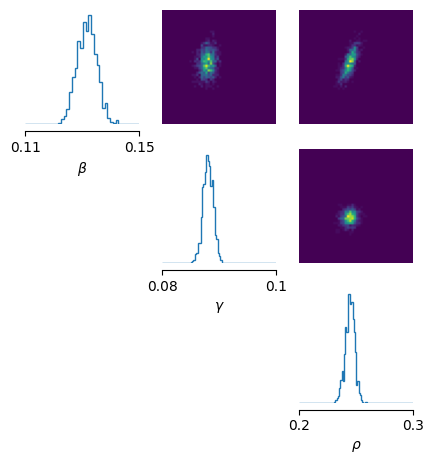

In [13]:
from sbi.analysis import pairplot

f, ax = pairplot(
    samples.cpu(),
    limits=[[0.11, 0.15], [0.08, 0.10], [0.2, 0.3]],
    ticks=[[0.11, 0.15], [0.08, 0.10], [0.2, 0.3]],
    figsize=(5, 5),
    labels=[PARAM_LABELS[param] for param in PARAM_NAMES]
)
f.savefig(OUTPUT_DIR / "npe_pairwise_posterior")


In [14]:
def robust_mode_3d(data, bins=30, refine_percentile=10):
    """
    Robust mode estimate for 3D continuous data using 2-stage histogram + refinement.

    Parameters:
    - data: (N, 3) array
    - bins: coarse histogram resolution
    - refine_percentile: fraction of points kept around peak region

    Returns:
    - mode estimate (3,)
    """

    # ---------------------------
    # Step 1: coarse histogram
    # ---------------------------
    hist, edges = np.histogramdd(data, bins=bins)
    idx = np.unravel_index(np.argmax(hist), hist.shape)

    # ---------------------------
    # Step 2: extract points in densest bin
    # ---------------------------
    mask = np.ones(len(data), dtype=bool)
    for i in range(3):
        mask &= (
            (data[:, i] >= edges[i][idx[i]]) &
            (data[:, i] < edges[i][idx[i] + 1])
        )

    core = data[mask]

    # fallback if bin is too sparse
    if len(core) < 10:
        return data.mean(axis=0)

    # ---------------------------
    # Step 3: refine using nearest points
    # ---------------------------
    center = core.mean(axis=0)
    dist = np.linalg.norm(data - center, axis=1)

    cutoff = np.percentile(dist, refine_percentile)
    refined = data[dist <= cutoff]

    # final estimate
    return refined.mean(axis=0)

from scipy.stats import gaussian_kde
from scipy.stats import kstest

def compute_posterior_estimates(accepted_params):
    posterior_mean = np.mean(accepted_params, axis=0)
    posterior_median = np.median(accepted_params, axis=0)

    posterior_mode = robust_mode_3d(accepted_params)

    return {
        "mean": posterior_mean,
        "median": posterior_median,
        "mode": posterior_mode
    }

def compute_metrics(accepted_params, true_params, posterior_estimates):
    rmise = np.sqrt(np.mean((accepted_params - true_params) ** 2, axis=0))
    rarmise = rmise / np.abs(true_params)
    ae_mean = np.abs(posterior_estimates["mean"] - true_params)
    rae_mean = ae_mean / np.abs(true_params)
    ae_mode = np.abs(posterior_estimates["mode"] - true_params)
    rae_mode = ae_mode / np.abs(true_params)
    ae_median = np.abs(posterior_estimates["median"] - true_params)
    rae_median = ae_median / np.abs(true_params)

    return {
        "rmise": rmise,
        "rarmise": rarmise,
        "ae_mean": ae_mean,
        "rae_mean": rae_mean,
        "ae_mode": ae_mode,
        "rae_mode": rae_mode,
        "ae_median": ae_median,
        "rae_median": rae_median
    }

def compute_pit(accepted_params, true_params):
    # compute the posterior quantile of the true parameters using the accepted parameters
    n_params = true_params.shape[0]
    quantiles = []
    for i in range(n_params):
        quantile = np.mean(accepted_params[:, i] < true_params[i])
        quantiles.append(quantile)
    return np.array(quantiles)

def test_coverage(pit_list):
    # conduct Kolmogorov-Smirnov test for uniform distribution of posterior quantiles
    n_params = pit_list[0].shape[0]
    p_values = []
    ks_values = []
    for i in range(n_params):
        param_pits = [pit[i] for pit in pit_list]
        ks_value, p_value = kstest(param_pits, "uniform")
        ks_values.append(ks_value)
        p_values.append(p_value)
    return ks_values, p_values

In [15]:
# Point estimates
samples_numpy = np.array(samples.cpu())
posterior_estimates = compute_posterior_estimates(samples_numpy)

C:\Users\ningc\AppData\Local\Temp\ipykernel_29404\3473699662.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  samples_numpy = np.array(samples.cpu())


In [30]:
from scipy.stats import gaussian_kde

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Marginal KDE plots — one panel per parameter, all methods overlaid
# ══════════════════════════════════════════════════════════════════════════════
def plot_marginal_kdes(posterior_samples, param_names, save_path="marginal_kdes.pdf"):
    fig, axes = plt.subplots(1, len(param_names), figsize=(4.5 * len(param_names), 3.5))

    for ax, param in zip(axes, param_names):
        m = "npe"
        pidx = param_names.index(param)
        samples = posterior_samples[:, pidx]
        kde     = gaussian_kde(samples, bw_method="scott")
        xs      = np.linspace(samples.min(), samples.max(), 400)
        ax.plot(xs, kde(xs),
                color="black",
                label="APT-MAF",
        )

        ax.set_xlabel(PARAM_LABELS[param], fontsize=12)
        ax.set_ylabel("Density" if param == param_names[0] else "", fontsize=11)
        ax.tick_params(labelsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="right",
               fontsize=9)

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    fig.suptitle(r"APT-MAF", fontsize=12, y=1.01)
    plt.close(fig)
    print(f"Saved: {save_path}")
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# 2.  RF posterior summary table  (mode, mean, median, 95 % HPD)
# ══════════════════════════════════════════════════════════════════════════════
def hpd_interval(samples, credmass=0.95):
    """Highest posterior density interval via sorted window."""
    sorted_s = np.sort(samples)
    n        = len(sorted_s)
    window   = int(np.floor(credmass * n))
    widths   = sorted_s[window:] - sorted_s[:n - window]
    idx      = np.argmin(widths)
    return sorted_s[idx], sorted_s[idx + window]

def kde_mode(samples):
    kde = gaussian_kde(samples, bw_method="scott")
    xs  = np.linspace(samples.min(), samples.max(), 2000)
    return xs[np.argmax(kde(xs))]

def build_rf_summary_table(posterior_samples, param_names):
    rows = []
    for param in param_names:
        pidx    = param_names.index(param)
        samples = posterior_samples[:, pidx]
        lo, hi  = hpd_interval(samples, 0.95)
        rows.append({
            "Parameter": PARAM_LABELS[param],
            "Mode":      f"{kde_mode(samples):.4f}",
            "Mean":      f"{samples.mean():.4f}",
            "Median":    f"{np.median(samples):.4f}",
            "95% HPD interval": f"[{lo:.4f}, {hi:.4f}]",
        })
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# 3.  RF pairwise joint posterior plot
# ══════════════════════════════════════════════════════════════════════════════
def plot_pairwise_joint(posterior_samples, param_names, save_path="npe_pairwise_joint.pdf"):
    n     = len(param_names)
    color = "black"

    adjusted = posterior_samples

    fig, axes = plt.subplots(1, len(param_names), figsize=(4 * len(param_names), 3.5))

    for ax, param in zip(axes, param_names):

        pidx = param_names.index(param)
        qidx = (pidx + 1) % n

        # lower triangle — 2-D KDE contour
        x, y = adjusted[:, pidx], adjusted[:, qidx]
        k    = gaussian_kde(np.vstack([x, y]), bw_method="scott")
        xg   = np.linspace(x.min(), x.max(), 80)
        yg   = np.linspace(y.min(), y.max(), 80)
        X, Y = np.meshgrid(xg, yg)
        Z    = k(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
        ax.contourf(X, Y, Z, levels=6, cmap="Grays", alpha=0.85)
        cs = ax.contour(X, Y, Z,  levels=6, colors=color, linewidths=0.6, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

        # posterior mode (grid approximation)
        max_idx = np.unravel_index(np.argmax(Z), Z.shape)
        mode_x = X[max_idx]
        mode_y = Y[max_idx]

        ax.set_xlabel(PARAM_LABELS[param_names[pidx]], fontsize=12)
        ax.set_ylabel(PARAM_LABELS[param_names[qidx]], fontsize=12)

        # plot the mode point
        ax.scatter(mode_x, mode_y, color="red", s=50, zorder=5, label="mode")

        # label with numeric value
        label = f"({mode_x:.2f}, {mode_y:.2f})"

        ax.annotate(
            label,
            xy=(mode_x, mode_y),
            xytext=(10, 10),
            textcoords="offset points",
            color="red",
            fontsize=9,
        )

    fig.suptitle(r"APT-MAF", fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print(f"Saved: {save_path}")
    return fig

Saved: ..\results\advanced\npe_marginal_kdes.png

RF posterior summary
Parameter   Mode   Mean Median 95% HPD interval
  $\beta$ 0.1322 0.1315 0.1316 [0.1254, 0.1385]
 $\gamma$ 0.0879 0.0880 0.0880 [0.0862, 0.0896]
   $\rho$ 0.2443 0.2445 0.2446 [0.2362, 0.2524]
Saved: ..\results\advanced\npe_pairwise_joint.png


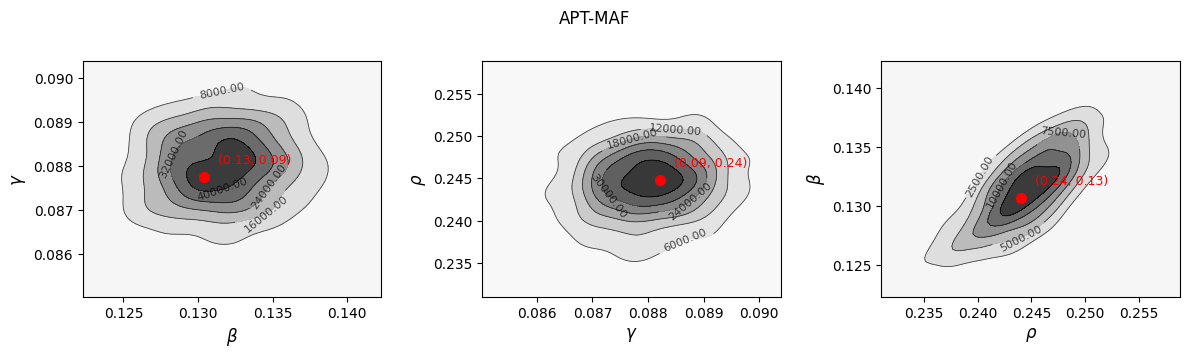

In [31]:
# ── 1. Marginal KDEs ──────────────────────────────────────────────────
plot_marginal_kdes(samples_numpy, PARAM_NAMES,
                    save_path=OUTPUT_DIR / "npe_marginal_kdes.png")

# ── 2. RF summary table ───────────────────────────────────────────────
rf_summary = build_rf_summary_table(samples_numpy, PARAM_NAMES)
print("\nRF posterior summary")
print(rf_summary.to_string(index=False))
rf_summary.to_csv(OUTPUT_DIR / "npe_posterior_summary.csv", index=False)

# ── 3. Pairwise joint posterior ───────────────────────────────────────
plot_pairwise_joint(samples_numpy, PARAM_NAMES,
                    save_path=OUTPUT_DIR / "npe_pairwise_joint.png")

In [20]:
# simulation-based-calibration
from sbi.analysis.plot import sbc_rank_plot
from sbi.diagnostics import check_sbc, run_sbc

eps = 0.01
thetas = torch.tensor(obs_data[eps][PARAM_NAMES].values, dtype=torch.float32).to(device)
xs = torch.tensor(obs_data[eps][SUMMARY_NAMES].values, dtype=torch.float32).to(device)
num_posterior_samples = 1_000

print(thetas.shape)
print(xs.shape)

ranks, dap_samples = run_sbc(
    thetas,
    xs,
    posterior,
    num_posterior_samples=num_posterior_samples,
)
check_stats = check_sbc(ranks, thetas, dap_samples, num_posterior_samples)
print(check_stats)

c:\Users\ningc\Documents\university\bachelor-4\semester-2\simulation\project\.venv\Lib\site-packages\sbi\utils\diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 1000 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


torch.Size([100, 3])
torch.Size([100, 22])


Drawing 1000 samples for 100 observations: 1192it [00:01, 679.57it/s]                         
Calculating ranks for 100 SBC samples: 100%|██████████| 100/100 [00:00<00:00, 3105.99it/s]


{'ks_pvals': tensor([0.2527, 0.1577, 0.7511]), 'c2st_ranks': tensor([0.4850, 0.5600, 0.4500], dtype=torch.float64), 'c2st_dap': tensor([0.3900, 0.3700, 0.3300], dtype=torch.float64)}


In [21]:
check_stats = check_sbc(
    ranks, thetas, dap_samples, num_posterior_samples=num_posterior_samples
)

In [22]:
print(check_stats)
pd.DataFrame(check_stats).to_csv(OUTPUT_DIR / "sbc_check_stats.csv")

{'ks_pvals': tensor([0.2527, 0.1577, 0.7511]), 'c2st_ranks': tensor([0.4200, 0.5450, 0.5100], dtype=torch.float64), 'c2st_dap': tensor([0.3900, 0.3700, 0.3300], dtype=torch.float64)}


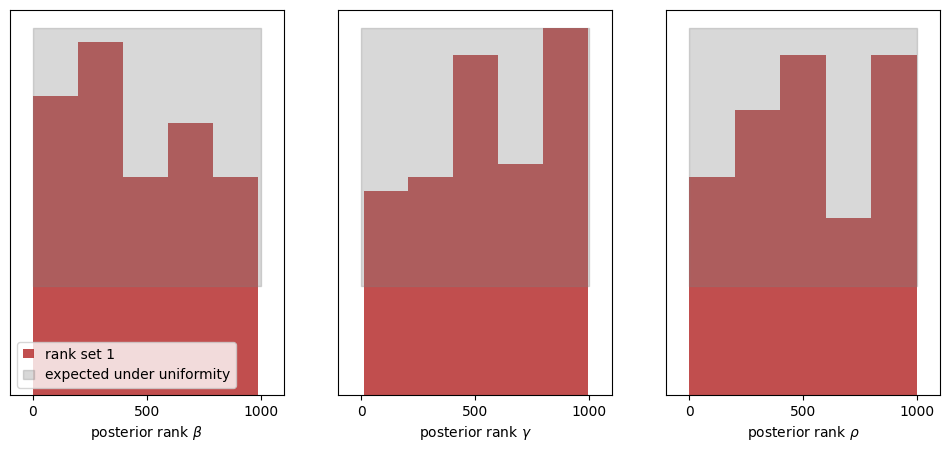

In [23]:
f, ax = sbc_rank_plot(
    ranks,
    1_000,
    plot_type="hist",
    parameter_labels=[PARAM_LABELS[pname] for pname in PARAM_NAMES]
)
f.savefig(OUTPUT_DIR / "sbc_rank_plot_hist.png")

In [25]:
OUTPUT_DIR

WindowsPath('../results/advanced')

Saved: npe_marginal_comparison.png


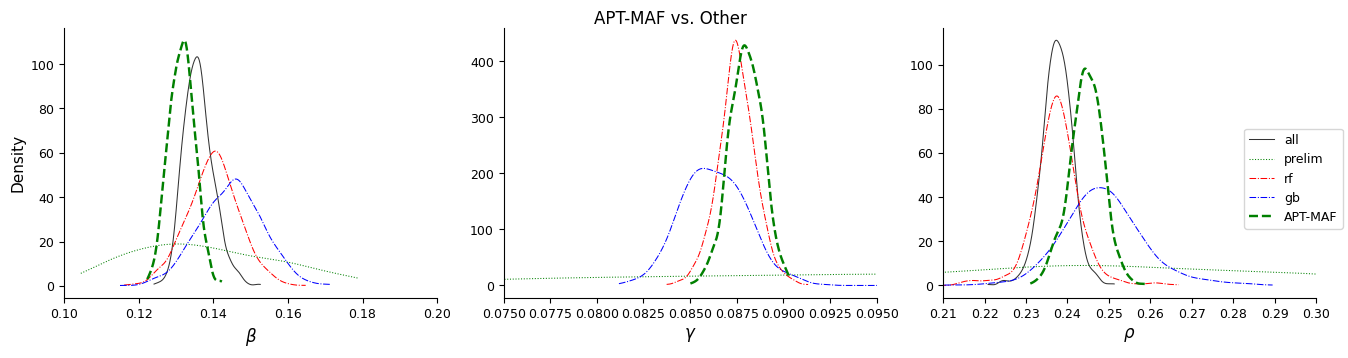

In [35]:
# Comparison with preliminary, all, rf, gb
PRELIM_DIR = Path("../results/preliminary")
SUMMARY_DIR = Path("../results/summary")

base_posterior_samples = np.load(PRELIM_DIR / "base_posterior_samples.npy")
all_posterior_samples = np.load(SUMMARY_DIR / "all_posterior_samples.npy")
rf_posterior_samples = np.load(SUMMARY_DIR / "rf_posterior_samples.npy")
gb_posterior_samples = np.load(SUMMARY_DIR / "gb_posterior_samples.npy")

posterior_samples = {
    "base": base_posterior_samples,
    "npe": samples_numpy,
    "all": all_posterior_samples,
    "rf": rf_posterior_samples,
    "gb": gb_posterior_samples
}

n_rows = len(posterior_samples)
n_cols = 3

from scipy.stats import gaussian_kde

# ── colour palette (consistent across all plots) ──────────────────────────
METHODS = ["all", "base", "rf", "gb", "npe"]
METHOD_COLORS = {
    "all":      "#333333",   # light grey
    "base":      "green",       # green
    "rf":   "red",         # red
    "gb":   "blue",   # dark grey
    "npe":  "green",        # blue
}

METHOD_LABELS = {
    "all": "all",
    "base": "prelim",
    "pls": "pls",
    "rf": "rf",
    "gb": "gb",
    "npe": "APT-MAF"
}

METHOD_LINESTYLE = {
    "all":      "-",
    "base":      ":",
    "pls":  "-",
    "rf":   "-.",
    "gb":   "-.",
    "npe":       "--",
}

xlims = {
    "beta": (0.10, 0.20),
    "gamma": (0.075, 0.095),
    "rho": (0.21, 0.3)
}

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Marginal KDE plots — one panel per parameter, all methods overlaid
# ══════════════════════════════════════════════════════════════════════════════
def plot_marginal_kdes(posterior_samples, param_names, methods, save_path="marginal_kdes.pdf"):
    fig, axes = plt.subplots(1, len(param_names), figsize=(4.5 * len(param_names), 3.5))

    for ax, param in zip(axes, param_names):
        pidx = param_names.index(param)
        for m in methods:
            samples = posterior_samples[m][:, pidx]
            kde     = gaussian_kde(samples, bw_method="scott")
            xs      = np.linspace(samples.min(), samples.max(), 400)
            ax.plot(xs, kde(xs),
                    color=METHOD_COLORS[m],
                    label=METHOD_LABELS[m],
                    linestyle=METHOD_LINESTYLE[m],
                    linewidth=(1.75 if m in("rf.glob", "npe") else 0.75))

        ax.set_xlabel(PARAM_LABELS[param], fontsize=12)
        ax.set_ylabel("Density" if param == param_names[0] else "", fontsize=11)
        ax.set_xlim(xlims[param])
        ax.tick_params(labelsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="right",
               fontsize=9)

    fig.tight_layout()
    fig.suptitle(r"APT-MAF vs. Other", fontsize=12, y=1.01)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print(f"Saved: {save_path}")
    return fig

plot_marginal_kdes(posterior_samples, PARAM_NAMES, METHODS, save_path=OUTPUT_DIR / "npe_marginal_comparison.png")